In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.metrics import silhouette_score, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
from typing import Optional
from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.inspection import permutation_importance
from sklearn.metrics import root_mean_squared_error
pd.set_option('display.max_columns', None)

In [56]:
train = pd.read_csv("train_earth.csv")
test = pd.read_csv("test_earth.csv")
train_gap = pd.read_csv("Gap_Train.csv")
test_gap = pd.read_csv("Gap_Test.csv")
variables = pd.read_csv("VariableDefinitions.csv")

In [71]:
soil_depth = 20
target_columns = ['N', 'P', 'K', 'Ca', 'Mg', 'S', 'Fe', 'Mn', 'Zn', 'Cu', 'B']

In [72]:
train_dropna = train.dropna().sort_values(by="PID")
X = train_dropna.drop(columns=target_columns)
Y = train_dropna[target_columns]

In [42]:
def scale_predictions(X, Y_pred):
    scale = X['BulkDensity'].values.reshape(-1, 1) * soil_depth * 0.1
    Y_scaled = Y_pred * scale
    return Y_scaled

In [6]:

def score_predictions(estimator, X, Y_true):
    Y_pred = estimator.predict(X)
    Y_true_final = scale_predictions(X, Y_true)
    Y_pred_final = scale_predictions(X, Y_pred)
    return -root_mean_squared_error(Y_true_final, Y_pred_final)


estimator_last_score = {}


def eval_model(estimator, X, Y, n_splits=5, estimator_key=None, n_jobs=1, print_result=True):
    result = cross_validate(estimator, X, Y, cv=n_splits,
                            scoring=score_predictions, n_jobs=n_jobs)
    scores = -result['test_score']
    mean = np.mean(scores)
    median = np.median(scores)
    if print_result:
        print("mean score:", mean)
        print("median score:", np.median(scores))
        print("std:", np.std(scores))
        print("scores:  ", scores)
    estimator_key = estimator_key or id(estimator)
    if print_result:
        if not estimator_key in estimator_last_score:
            print("first evaluation")
        else:
            last_mean, last_median = estimator_last_score[estimator_key]
            if mean < last_mean:
                print("mean improved")
            elif mean > last_mean:
                print("mean degraded")
            else:
                print("same mean")

            if median < last_median:
                print("median improved")
            elif median > last_median:
                print("median degraded")
            else:
                print("same median")

    estimator_last_score[estimator_key] = (mean, median)
    return result

In [7]:
def eval_classifier(classifier, X, y, n_splits=5, n_jobs=1, print_result=True):
    result = cross_validate(classifier, X, y, cv=n_splits,
                            scoring='roc_auc_ovr', n_jobs=n_jobs)
    scores = result['test_score']
    if print_result:
        print("mean score:", np.mean(scores))
        print("median score:", np.median(scores))
        print("std:", np.std(scores))
        print("scores:  ", scores)
    return result

In [8]:
def predict(model, test):
    predictions = model.predict(test)
    predictions = scale_predictions(test, predictions)
    predictions = pd.DataFrame(
        predictions, columns=target_columns, index=test.index)
    predictions["PID"] = test["PID"]
    predictions = predictions.melt(
        id_vars=['PID'], var_name='Nutrient', value_name='Available')
    predictions = predictions.merge(right=test_gap, on=["PID", "Nutrient"])
    predictions["Gap"] = predictions["Required"] - predictions["Available"]
    predictions['ID'] = predictions['PID'] + "_" + predictions['Nutrient']
    predictions = predictions[["ID", "Gap"]]
    return predictions

In [9]:
drop_step = ("drop", FunctionTransformer(
    lambda x: x.drop(columns=["PID", "site", 'Nadir_Reflectance_Band2', 'Nadir_Reflectance_Band4', 'QA_RADSAT',
                              'SENSING_ORBIT_NUMBER', 'SR_B1', 'SR_B2', 'SR_B4', 'SR_B6', 'SolarZenith', 'ecec20',
                              'lstn', 'para', 'relativeOrbitNumber_start', 'sur_refl_b07', 'tim'])))

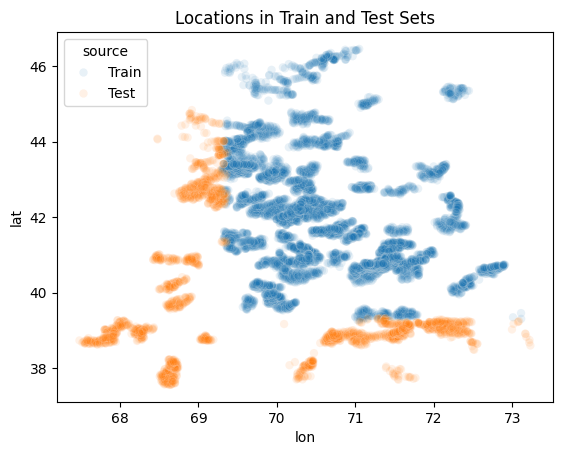

In [10]:
locations = pd.concat([
    train[['lat', 'lon']].assign(source='Train'),
    test[['lat', 'lon']].assign(source='Test')])
sns.scatterplot(x=locations['lon'],
                y=locations['lat'],
                alpha=0.1,
                hue=locations['source'])
plt.title("Locations in Train and Test Sets")
plt.show()

clustering: 100%|██████████| 11/11 [00:17<00:00,  1.63s/it]

best clustering, 2


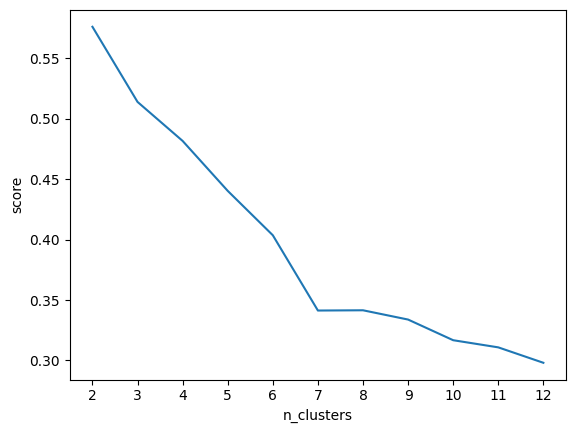

In [26]:
n_clusters_range = range(2, 13)
results = pd.DataFrame({"n_clusters": n_clusters_range, "score": None})
for i, n_clusters in enumerate(tqdm(n_clusters_range, desc="clustering")):
    kmeans = KMeans(n_clusters=n_clusters)
    target_cluster_k = kmeans.fit_predict(Y)
    results.iloc[i, 1] = silhouette_score(X=Y, labels=target_cluster_k)
sns.lineplot(x=results['n_clusters'], y=results['score'])
print(f"best clustering, {results.iloc[np.argmax(results['score']), 0]}")
plt.xticks(n_clusters_range)
plt.show()

In [73]:
kmeans = KMeans(n_clusters=2)
target_cluster = pd.Series(data=kmeans.fit_predict(Y), index=Y.index)
silhouette_score(X=Y, labels=target_cluster)

np.float64(0.5766649551809556)

In [59]:
max_nutrient = train_dropna[target_columns].apply(
    lambda x: np.argmax(x), axis=1).map(lambda x: target_columns[x])
max_nutrient_encoded = max_nutrient == 'Ca'
max_nutrient.value_counts()

Ca    6196
N     1539
Name: count, dtype: int64

Plotting: 100%|██████████| 11/11 [00:14<00:00,  1.32s/it]


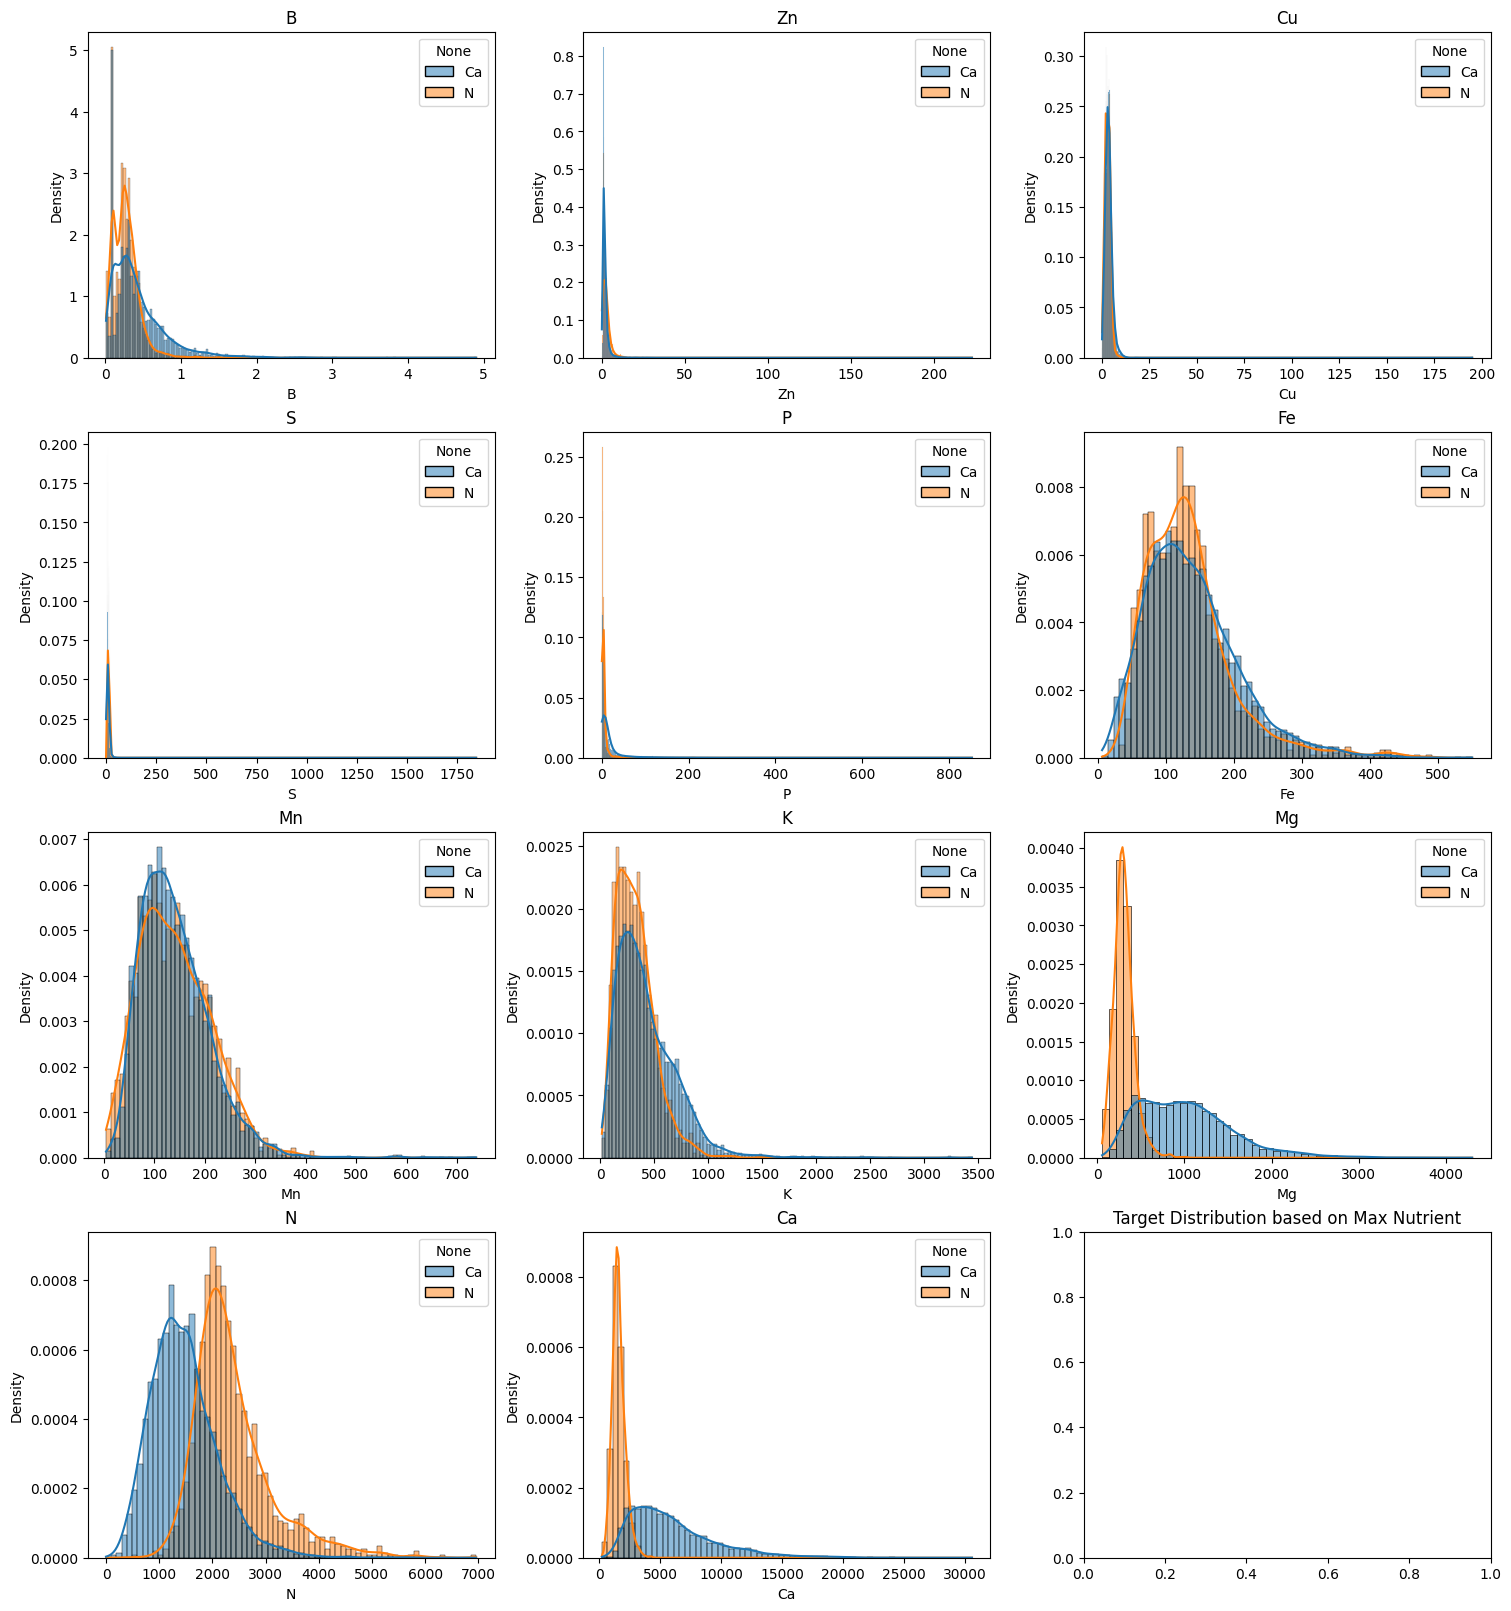

In [14]:
column_count = len(target_columns)
nrows = (column_count + 2) // 3
ncols = min(column_count, 3)
fig, axs = plt.subplots(nrows=nrows, ncols=ncols,
                        figsize=(5*ncols, 4*nrows),
                        constrained_layout=True)
axs = axs.reshape(-1)
for i, col in enumerate(tqdm(target_columns, desc="Plotting")):
    axs[i].set_title(col)
    sns.histplot(hue=max_nutrient, x=train_dropna[col], ax=axs[i],
                 stat='density',  # Normalizes each hue group separately
                 common_norm=False,  # Each hue gets its own scale
                 kde=True, )
plt.title("Target Distribution based on Max Nutrient")
plt.show()

In [74]:
from sklearn.ensemble import HistGradientBoostingClassifier
is_ca_max_hist = Pipeline(
    [("drop", FunctionTransformer(lambda x: x.drop(columns=["PID", "site", 'mb1', 'mdem', 'QA_PIXEL', 'VH']))),
     ("c", ColumnTransformer(
         [('log',  FunctionTransformer(np.log1p),
           ['B7', 'MEAN_SOLAR_ZENITH_ANGLE']),],
         remainder='passthrough', force_int_remainder_cols=False)),
     ("hist", HistGradientBoostingClassifier(random_state=0
                                             ))])


eval_classifier(is_ca_max_hist, X,
                max_nutrient_encoded, n_jobs=-1, n_splits=4)

mean score: 0.9642203879615112
median score: 0.9636138662284562
std: 0.00404297536112065
scores:   [0.95963713 0.97001668 0.9658548  0.96137293]


{'fit_time': array([2.73002458, 2.67785072, 2.72414017, 2.68904829]),
 'score_time': array([0.05616403, 0.04636669, 0.04899025, 0.04073048]),
 'test_score': array([0.95963713, 0.97001668, 0.9658548 , 0.96137293])}

In [75]:
from sklearn.ensemble import HistGradientBoostingClassifier
target_cluster_hist = Pipeline(
    [("drop", FunctionTransformer(lambda x: x.drop(columns=["PID", "site", 'mdem', 'QA_PIXEL']))),
     ("c", ColumnTransformer(
         [('log',  FunctionTransformer(np.log1p),
           ['B8A', 'CLOUDY_PIXEL_PERCENTAGE',
             'MEAN_SOLAR_ZENITH_ANGLE', 'NODATA_PIXEL_PERCENTAGE']),],
         remainder='passthrough', force_int_remainder_cols=False)),
     ("hist", HistGradientBoostingClassifier(random_state=0
                                             ))])
eval_classifier(target_cluster_hist, X,
                target_cluster, n_jobs=-1, n_splits=4)

mean score: 0.9651177741028297
median score: 0.9654272559776307
std: 0.0018735395078099538
scores:   [0.96646805 0.96241132 0.96438647 0.96720527]


{'fit_time': array([3.22412944, 3.33165717, 3.21515489, 3.21172714]),
 'score_time': array([0.04888821, 0.03954363, 0.04603028, 0.05114698]),
 'test_score': array([0.96646805, 0.96241132, 0.96438647, 0.96720527])}

In [76]:
classifier_columns = X.columns
is_ca_max_hist.fit(X, max_nutrient_encoded)

target_cluster_hist.fit(X, target_cluster)

Pipeline(steps=[('drop',
                 FunctionTransformer(func=<function <lambda> at 0x000001E3847104A0>)),
                ('c',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  ['B8A',
                                                   'CLOUDY_PIXEL_PERCENTAGE',
                                                   'MEAN_SOLAR_ZENITH_ANGLE',
                                                   'NODATA_PIXEL_PERCENTAGE'])])),
                ('hist', HistGradientBoostingClassifier(random_state=0))])

In [77]:
def add_is_ca_max_nutrient(X: pd.DataFrame):
    X = X.copy()
    X['is_ca_max_nutrient'] = is_ca_max_hist.predict(X[classifier_columns])
    return X

In [78]:
def add_target_cluster(X: pd.DataFrame):

    X = X.copy()

    X['target_cluster'] = target_cluster_hist.predict(X[classifier_columns])

    return X

In [79]:
from sklearn.ensemble import HistGradientBoostingRegressor


from sklearn.multioutput import MultiOutputRegressor
hist = Pipeline([('target_cluster', FunctionTransformer(add_target_cluster)),
                 ('is_ca_max_nutrient', FunctionTransformer(add_is_ca_max_nutrient)),
                 drop_step,
                 ("hist", MultiOutputRegressor(HistGradientBoostingRegressor(random_state=0,
                                                                             max_iter=350,
                                                                             learning_rate=0.1,
                                                                             loss='squared_error'),
                                               n_jobs=2))])
eval_model(hist, X, Y, n_jobs=4, n_splits=4, estimator_key="hist")

mean score: 536.3784220836483
median score: 529.6838152068208
std: 12.057148280692424
scores:   [529.00661207 530.36101834 528.90773607 557.23832185]
mean improved
median improved


{'fit_time': array([84.65011263, 84.2993257 , 83.9082706 , 84.27128053]),
 'score_time': array([0.96771598, 0.99036598, 0.70612931, 1.08619308]),
 'test_score': array([-529.00661207, -530.36101834, -528.90773607, -557.23832185])}

In [80]:
from xgboost import XGBRegressor
xgb_regressor = Pipeline([('target_cluster', FunctionTransformer(add_target_cluster)),
                          ('is_ca_max_nutrient', FunctionTransformer(
                              add_is_ca_max_nutrient)),
                          drop_step,
                          ("xgb", XGBRegressor(
                              random_state=0,
                              n_estimators=300,
                              max_depth=10,
                              learning_rate=0.025,
                              subsample=0.6,
                              tree_method="hist",
                              device="cuda"),
                           )])
eval_model(xgb_regressor, X, Y, n_jobs=-1, n_splits=4, estimator_key="xgb")

mean score: 528.6829613379904
median score: 518.8429986879535
std: 19.258574637270588
scores:   [518.60545592 519.08054145 515.1118318  561.93401618]
mean improved
median improved


{'fit_time': array([190.57510829, 190.69093204, 190.23512173, 191.35805511]),
 'score_time': array([0.39463234, 0.31952477, 0.31432652, 0.2005558 ]),
 'test_score': array([-518.60545592, -519.08054145, -515.1118318 , -561.93401618])}

In [ ]:
xgb_regressor.fit(X, Y)

In [ ]:
predictions = predict(xgb_regressor, test)
predictions.to_csv("submissions/xgb_submission.csv", index=False)
predictions.head()

,ID,Gap
0,ID_NGS9Bx_B,-1.694153
1,ID_YdVKXw_B,-2.097765
2,ID_MZAlfE_B,-1.738838
3,ID_GwCCMN_B,-1.792734
4,ID_K8sowf_B,-1.795143


In [ ]:
model = Pipeline([('target_cluster', FunctionTransformer(add_target_cluster)),
                 ('is_ca_max_nutrient', FunctionTransformer(add_is_ca_max_nutrient)),
                 drop_step,
                 ("hist", MultiOutputRegressor(HistGradientBoostingRegressor(random_state=0,
                                                                             max_iter=350,
                                                                             learning_rate=0.1,
                                                                             loss='squared_error'),
                                               n_jobs=2))])
eval_model(hist, X, Y, n_jobs=4, n_splits=4, estimator_key="hist")
full_mean = 532
full_median = 529
for col in tqdm(X.columns):
    print(f"testing {col}:")
    try:
        X_t = X.drop(columns=[col])
        result = eval_model(model, X, Y, n_jobs=4, n_splits=4, print_results = False)
        col_mean = np.mean(-result['test_score'])
        col_median = np.median(-result['test_score'])
        
    except:
        print(col,"failed")
